In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

df = pd.read_csv('/content/heart.csv')
print(df.shape)
print(df.isnull().sum())
df.head()

(918, 12)
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


First, let's go through the dataset features.

General features, such as **Age** and **Sex** and others that are related to presence (or absense) of heart issues.

**ChestPainType** - type of the pain experienced in case of heart issues, could be a key symptom.

**RestingBP** - resting blood pressure. High level of this parameter could be a risk factor.

**Cholesterol** - high cholesterol also is another risk factor for cardiovascular diseases (CVD).

**FastingBS** - fasting blood sugar level, here 1 stands for high levels, 0 - for normal levels. High blood sugar is associated with diabetes.

**RestingECG** - resting electrocardiogram.

*   Normal: normal ECG
*   ST: ST-T wave abnormality
*   LVH: probable or definite left ventricular hypertrophy

**MaxHR** - maximum heart rate under the exercise. Low heart rate can be a disease indicator.

**ExerciseAngina** - exercise-induced angina.

**OldPeak** - ST depression induced by exercise relative to rest. Higher ST could indicate ischemia.

**ST_Slope** - slope of the peak exercise ST segment.

* Up: usually a healthier sign
* Flat: could be a risk factor
* Down: strong assosiation with disease

**HeartDisease** - target value.


There are 918 patients in the dataset and no missing values for any feature.

Let's look at the target value - HeartDisease.

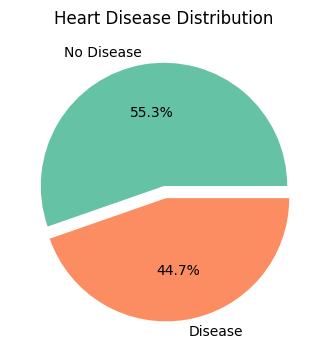

In [33]:
target_counts = df['HeartDisease'].value_counts()
colors = sns.color_palette("Set2")

plt.figure(figsize=(8, 4))
plt.pie(target_counts.values, labels=['No Disease', 'Disease'], autopct='%1.1f%%',
        colors=colors, explode=[0, 0.1])
plt.title('Heart Disease Distribution')
plt.show()

The dataset is quite balanced, 55.3% of patients do not have heart disease and 44.7% have.

### Distribution of the dataset features

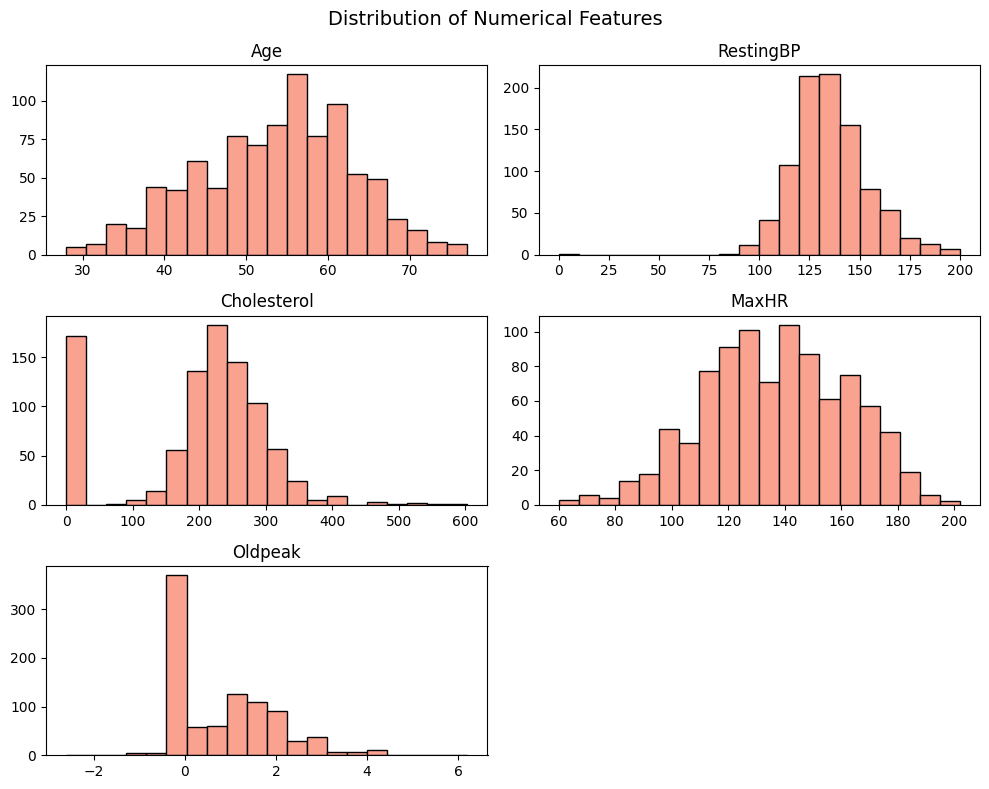

In [35]:
# Histograms for numerical features
selected_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df[selected_features].hist(figsize=(10, 8), bins=20, color='#f9a290', edgecolor='black', grid=False)
plt.suptitle('Distribution of Numerical Features', size=14)
plt.tight_layout()
plt.show()

**Age**: Patients' age range is from 20s to late 70s, with a higher propotion of older patients around 50-60s.

**RestingBP**: Blood pressure is normally distributed with mean around ~ 135. But there is presence of 0 value, which could be an error.

**Cholesterol**: Most of the values are in range of 150 to 300 mg/dl. It also contains a significant number of zero values.

**MaxHR**: Heart rate is normally distributed, cented around 140 bpm.

**Oldpeak**: Distribution is righ-skewed, a lot of patients have value near 0.





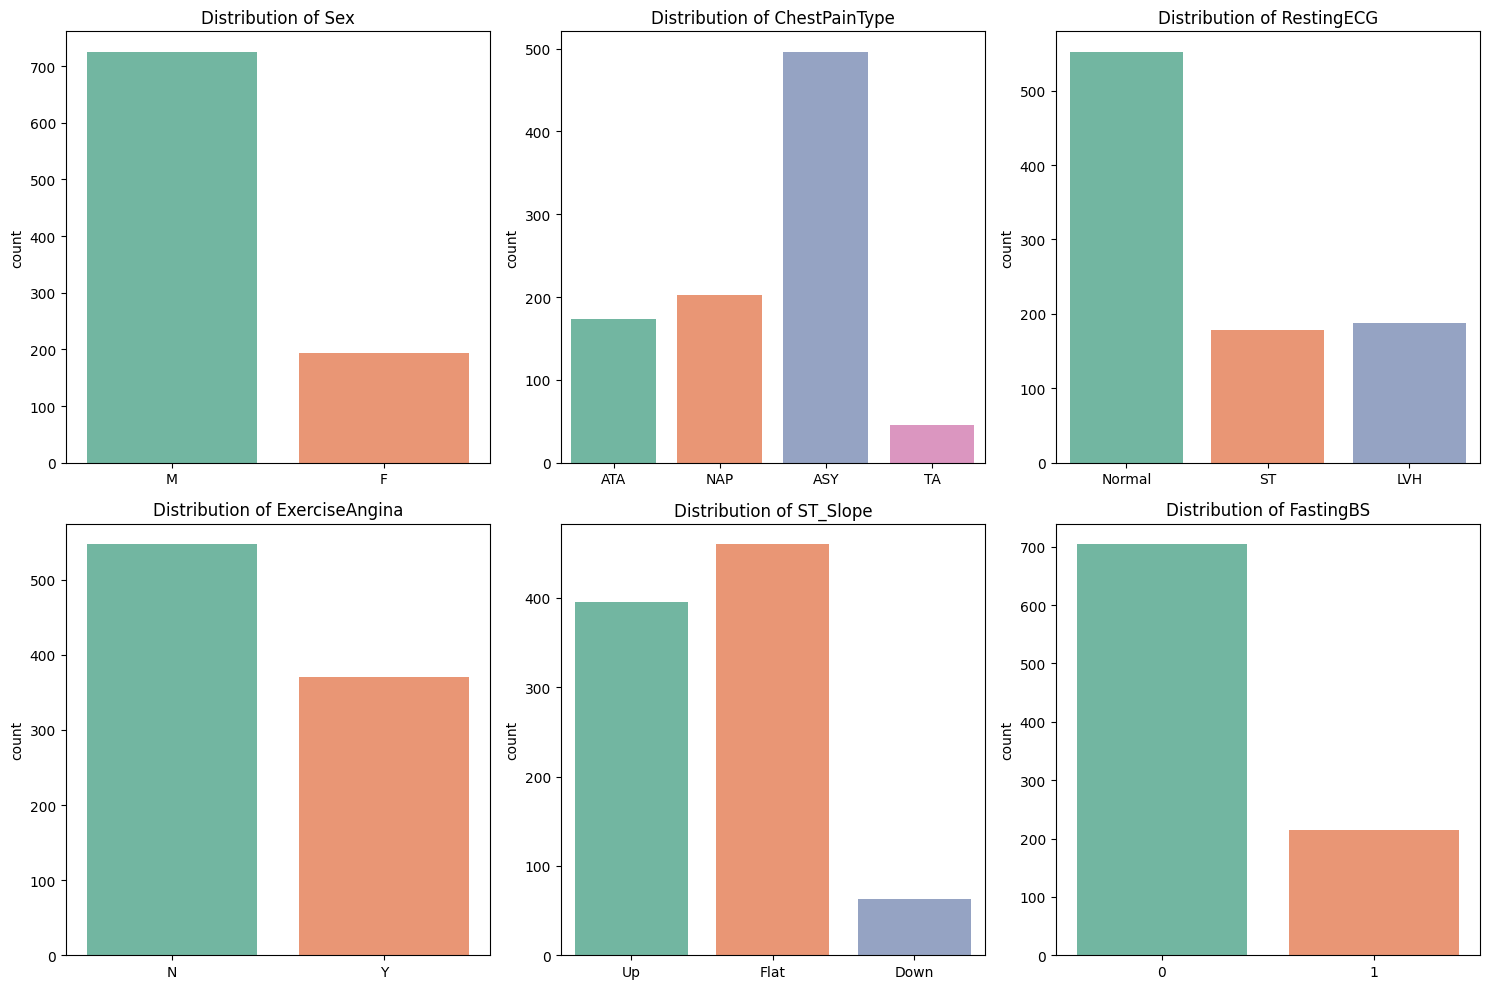

In [38]:
# Count plots for categorical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Sex**: The dataset is mostly male-dominated.

**ChestPainType**: The most frequently observed chest pain is Asymptomatic (ASY), so the absence of chest pain doesn't mean the absence of possible heart issues.

**RestingECG**: Most patients have normal ECG, but a significant number show ST-T wave abnormalities (ST).

**ExerciseAngina**: The majority of patients do not have exercise-induced angina.

**ST_Slope**: The "Flat" type is the most common, followed by "Up" and "Down".

**FastingBS**: Majority of patients have normal blood sugar level.

### Categorial Features impact on Heart Disease

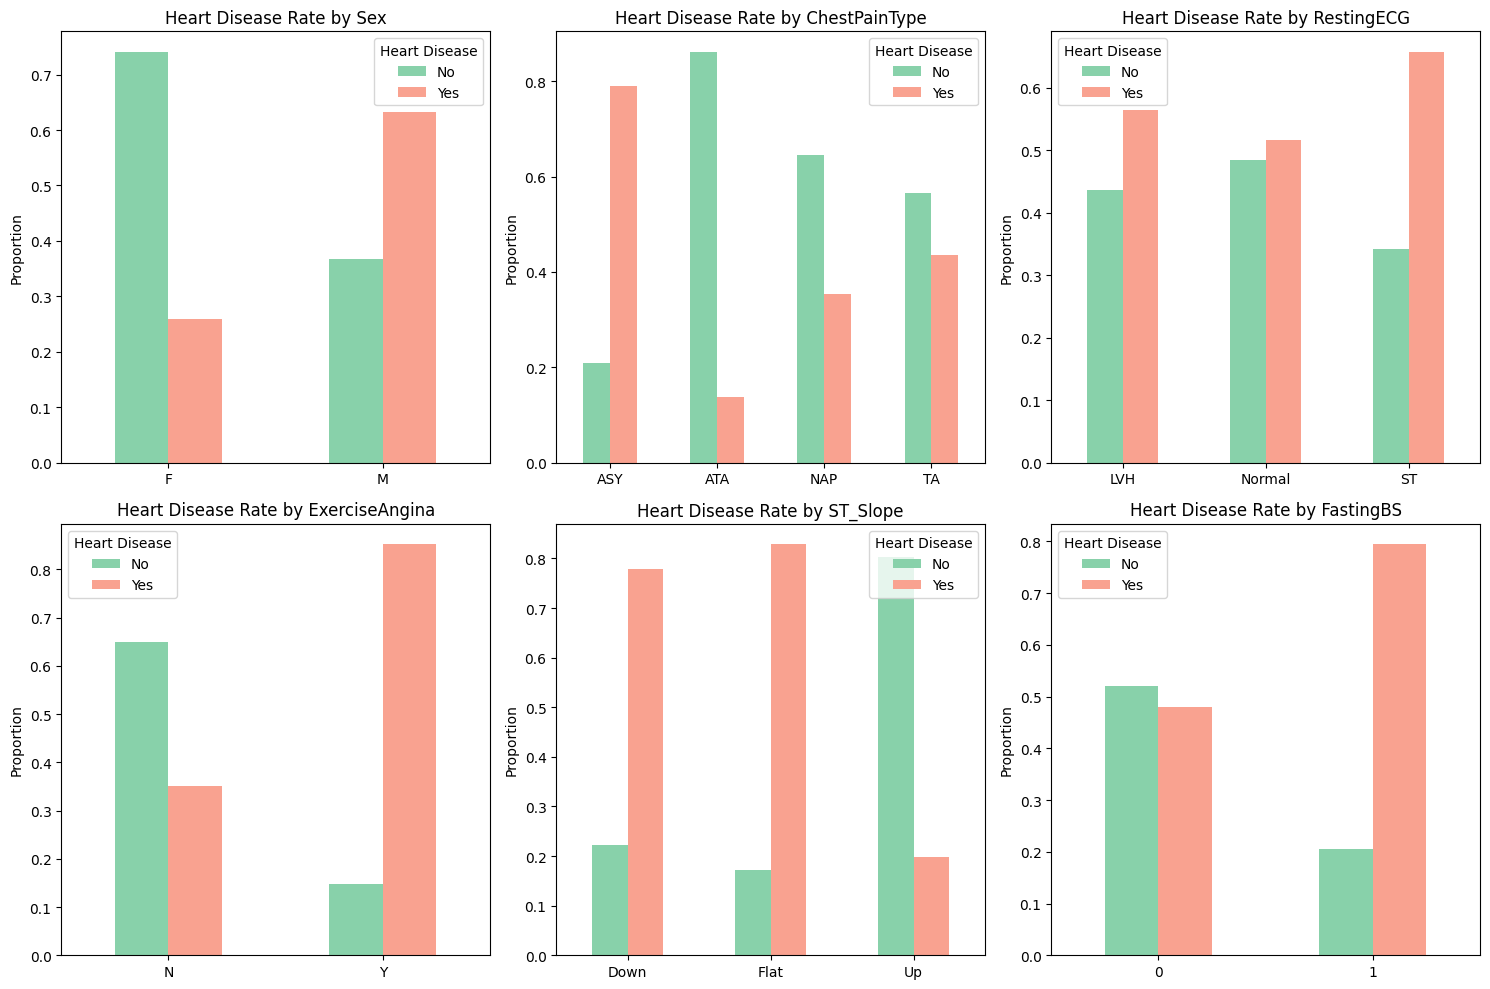

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['HeartDisease'], normalize='index').plot.bar(
        ax=axes[i], color=['#88d1aa','#f9a290'], rot=0)
    axes[i].set_title(f'Heart Disease Rate by {col}')
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel('')
    axes[i].legend(title='Heart Disease', labels=['No', 'Yes'])


plt.tight_layout()
plt.show()

**Sex**: It seems that based on the dataset CVD are more between men, then women. But it could be also influenced by the data's gender imbalance.

**ChestPainType**: This is a very strong predictor. Patients with Asymptomatic (ASY) chest pain have the highest rate of heart disease (around 80%). Patients with Typical Angina (TA) have the lowest rate (quite expected results).

**RestingECG**: Patients with ST (ST-T abnormality) show the highest rate of heart disease. LVH (left ventricular hypertrophy) also shows a high rate.

**ExerciseAngina**: The proportion of patients with heart disease is higher for those who experience Y (yes) exercise-induced angina compared to N (no). That's a strong predictor.

**ST_Slope**: Flat and Down sloping segments are associated with a very high rate of heart disease. An Up sloping segment is associated with a very low rate of disease.

**FastingBS**: Even though most of the patients have normal blood sugar, we can see that patients with high blood sugar level are likely to have heart issues.

All in all, main categorial predictors could be: **ChestPainType, ExerciseAngina, ST_Slope** and **FastingBS**.

### Numerical features impact on Heart Disease

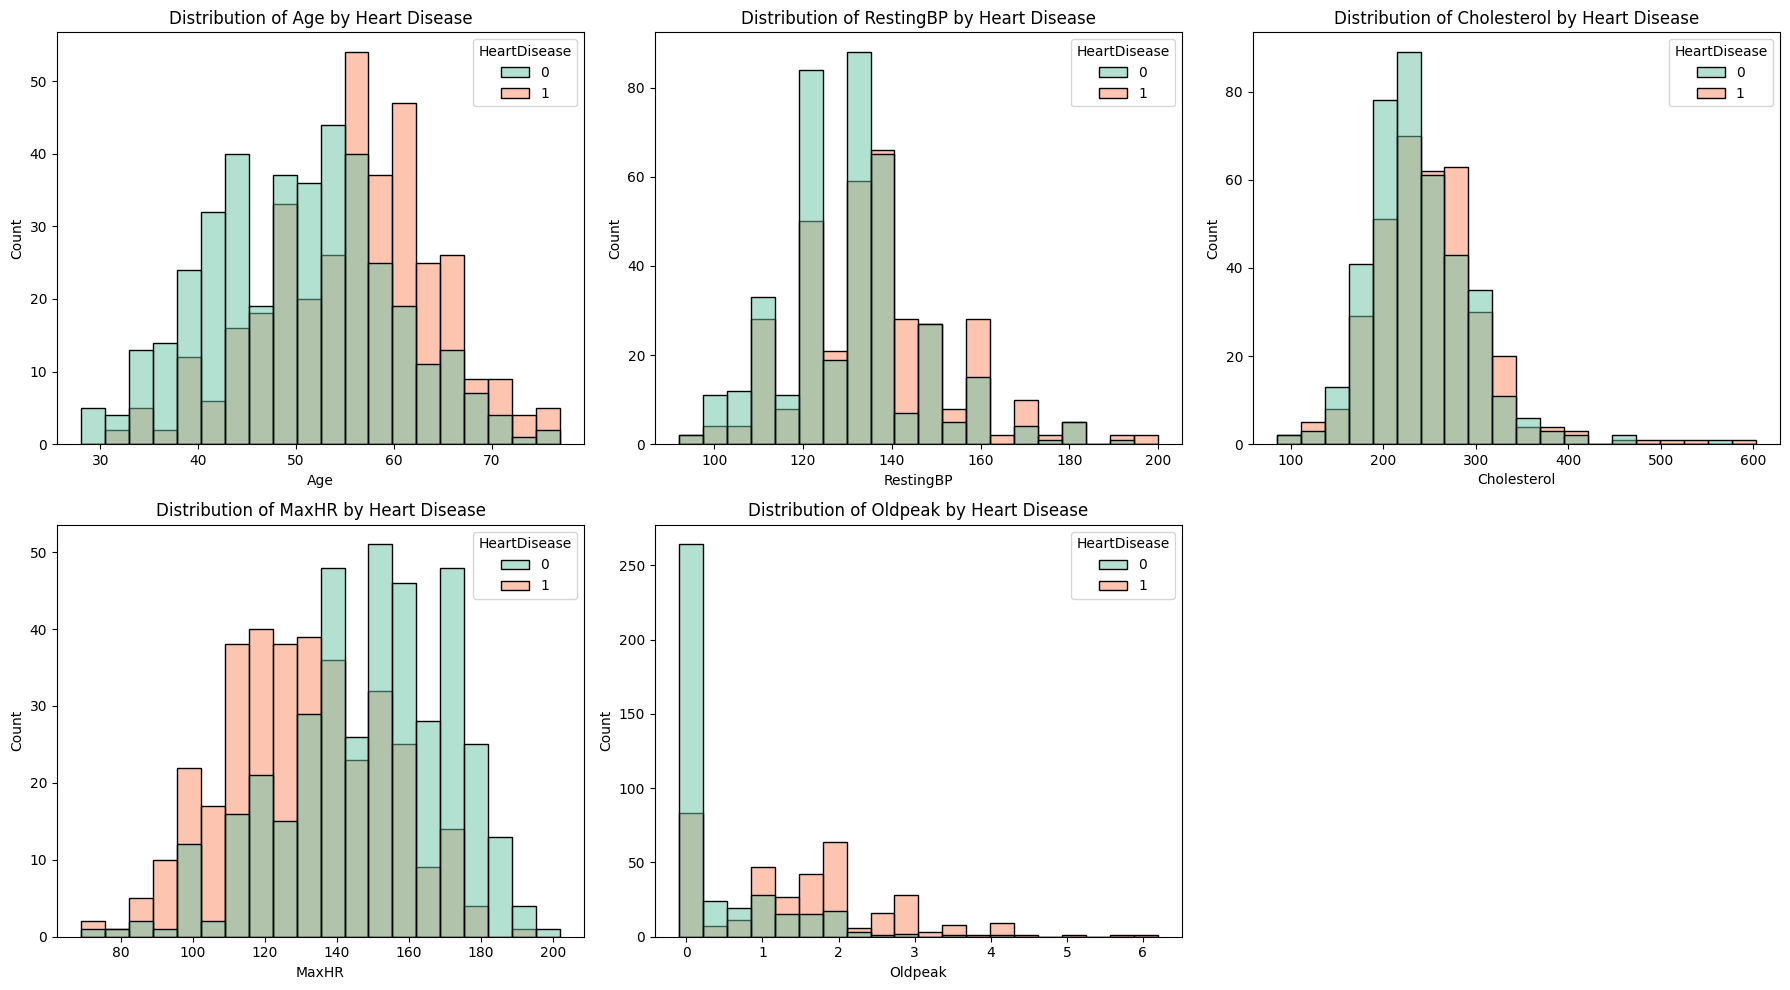

In [40]:
df_clean = df[(df['Cholesterol'] > 0) & (df['RestingBP'] > 0)]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for i, col in enumerate(num_cols):
    sns.histplot(data=df_clean, x=col, hue='HeartDisease', kde=False,
                 palette='Set2', ax=axes[i//3, i%3], bins=20)
    axes[i//3, i%3].set_title(f'Distribution of {col} by Heart Disease')

fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

We can clearly see that older patients are more likely to have heart issues than younger patients.

Both **RestingBP** and **Cholesterol** do not correlate with the disease that much. Distributions for both healthy and disease groups are likely the same.

**MaxHR** is a very strong predictor. Patients with heart disease have a significantly lower maximum heart rate compared to healthy patients.

Patients with heart disease have much higher Oldpeak values, indicating greater ST depression.

Summing up, main numerical predictors could be: **Age, MaxHR** and **Oldpeak**.

### Out of all features main predictors are **Age, MaxHR, Oldpeak, ChestPainType, ExerciseAngina, ST_Slope** and **FastingBS**.

Let's conduct the correlation analysis to find the strongest predictors.

In [45]:
df_analysis = df_clean.copy()

df_analysis['ChestPainType_encoded'] = df_analysis['ChestPainType'].map({
    'ASY': 3, 'ATA': 2, 'NAP': 1, 'TA': 0
})
df_analysis['ST_Slope_encoded'] = df_analysis['ST_Slope'].map({
    'Down': 2, 'Flat': 1, 'Up': 0
})
df_analysis['ExerciseAngina_encoded'] = (df_analysis['ExerciseAngina'] == 'Y').astype(int)

all_features = ['Age', 'MaxHR', 'Oldpeak', 'FastingBS',
                'ChestPainType_encoded', 'ST_Slope_encoded', 'ExerciseAngina_encoded']

correlations_all = {}
for feature in all_features:
    corr = df_analysis[feature].corr(df_analysis['HeartDisease'])
    correlations_all[feature] = corr

print("Features Impact on Heart Disease")
print("-" * 60)
print(f"{'Feature':<25} {'Correlation':<12} {'Impact Level':<15}")
print("-" * 60)

for feature, corr in sorted(correlations_all.items(), key=lambda x: abs(x[1]), reverse=True):
    if abs(corr) > 0.3:
        impact = "Very High"
    elif abs(corr) > 0.2:
        impact = "High"
    elif abs(corr) > 0.1:
        impact = "Moderate"
    else:
        impact = "Low"

    display_name = feature.replace('_encoded', '')
    print(f"{display_name:<25} {corr:+.3f}      {impact:<15}")

print("-" * 60)

Features Impact on Heart Disease
------------------------------------------------------------
Feature                   Correlation  Impact Level   
------------------------------------------------------------
ST_Slope                  +0.597      Very High      
ExerciseAngina            +0.552      Very High      
Oldpeak                   +0.496      Very High      
ChestPainType             +0.396      Very High      
MaxHR                     -0.377      Very High      
Age                       +0.299      High           
FastingBS                 +0.161      Moderate       
------------------------------------------------------------


### Conclusions
The dataset contains clinically impossible zero values in RestingBP and Cholesterol, which should be excluded.

The most powerful key predictors of heart disease in this dataset appear to be:

**ST_Slope**: Flat and Down strongly indicate disease.

**ExerciseAngina**: The presence of exercise-induced angina is a major risk factor.

**ChestPainType**: Asymptomatic chest pain type is highly associated with the disease.

**MaxHR**: A lower maximum heart rate is strongly associated with disease.

**Oldpeak**: Higher values are more common between patiens with disease.

Such features as **Age** and **FastingBS** have moderate effect, but are the weakest among selected features.

### Possible suggestions

1. Convert categorical features for easier analysis. For example, use One-Hot Encoding for features like ChestPainType, RestingECG, and ST_Slope.

2. Add Age groups: could be helpful to find any effect between different age groups, like 20-30s, 30-40s and etc.

3. Create groups based on MaxHR values, like Low, Normal and High. MaxHR appeared to be a strong predictor, so such binning could be helpful.